# KPS ridge-SLR — paper-ready results

The same assets as `kps_paper.ipynb`, for the **ridge-SLR campaign** (KPS-CV / KPS-GF) instead
of the ladder's (KPS-H / KPS-G).

**Nothing here touches the ladder's assets.** Different metrics cache, different output
directory, and `paper_assets.py` itself is unmodified — `paper_assets_cv` only rebinds its
campaign map inside this kernel.

| | campaign | cache | output |
|---|---|---|---|
| ladder (current paper) | KPSH, KPSG | `scripts/metrics.csv` | `notebooks/paper/` |
| ridge-SLR (here) | KPSCV, KPSGF | `scripts/metrics_cv.csv` | `notebooks/paper_cv/` |

**What differs in the method, and it is only the likelihood fit.** Ladder, prior-factor draw,
re-noising, handover and `V_t` are identical — `gen_samples_cv.py` asserts that against each
baseline's *stored* `config.yaml` before it will write an array, so the comparison is paired
arm for arm.

* **KPS-CV** replaces the hand-set rank-32 truncation with a ridge whose size is chosen by
  K-fold CV over the particles, takes `S_y` as the **full** Schur complement of the same
  regularised joint (df-corrected, no fold split), and solves matrix-free so the cost is
  independent of the rank.
* **KPS-GF** keeps G's exact-Jacobian slope and takes `S_y` as the full covariance of G's
  **own** linearisation residual, rather than the ladder's scalar built from a *regression*
  residual that G never uses.

The provenance limits from the ladder campaign **still apply unchanged**, because the problems
and their configs are the same: blackhole is not the benchmark's problem (`noise_type` is
`vis_thermal`, not `eht`), Navier–Stokes uses `sigma_noise = 1e-4` against the benchmark's 0,
and inverse scattering is the one directly comparable problem.

In [1]:
import sys, pathlib, importlib, pickle
sys.path.insert(0, '/mnt/home/gandry/kps/InverseBench/scripts')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import paper_assets as pa
import paper_assets_cv as cv
importlib.reload(pa); importlib.reload(cv)

OUT = cv.OUT
OUT.mkdir(parents=True, exist_ok=True)

def emit(name, tex):
    (OUT / name).write_text(tex + '\n')
    print(f'--- {name} ' + '-' * (62 - len(name)))
    print(tex)

df = cv.load_metrics()
print(df.groupby(['problem', 'algo', 'n']).size().rename('instances').to_string())

problem        algo   n  
blackhole      KPSCV  64     100
                      128    100
                      256    100
                      512    100
               KPSGF  16     100
inv-scatter    KPSCV  64     100
                      128    100
                      256    100
                      512    100
               KPSGF  16     100
navier-stokes  KPSCV  64      10
                      128     10
                      256     10
                      512     10


## 1. Experiment configuration (appendix)

Read from each run's **stored** `config.yaml`, so the table describes what actually ran.

In [2]:
emit('tab_config.tex', pa.config_table(df))
emit('tab_sampler.tex', pa.sampler_table())

--- tab_config.tex ------------------------------------------------
\small
\setlength{\tabcolsep}{4pt}
\sloppy
\begin{tabular}{@{}p{0.17\linewidth}p{0.28\linewidth}p{0.06\linewidth}p{0.22\linewidth}p{0.11\linewidth}@{}}
\toprule
Problem & Forward model & $\sigma_{\text{noise}}$ & Prior & Instances \\
\midrule
\raggedright\sloppy Black-hole imaging & \raggedright\sloppy EHT visibilities, 64$\times$64 image, \texttt{vis\_thermal} noise, \texttt{direct} transform & 0 & \raggedright\sloppy \texttt{\scriptsize blackhole-50k} & 100 (0--99) \\
\raggedright\sloppy Inverse scattering & \raggedright\sloppy 128$\times$128 permittivity, 20 transmitters $\times$ 360 receivers, wavenumber 6 & 0.0001 & \raggedright\sloppy \texttt{\scriptsize inv-scatter-5m} & 100 (0--99) \\
\raggedright\sloppy Navier--Stokes & \raggedright\sloppy vorticity at $t=1.0$, Re${}=200.0$, 128$^2$ downsampled $\times$2 & 0.0001 & \raggedright\sloppy \texttt{\scriptsize ns-5m} & 10 (0--9) \\
\bottomrule
\end{tabular}


--- tab_sampler.tex -----------------------------------------------
\begin{tabular}{llrrrrrrrr}
\toprule
Variant & Slope & $N$ & $T$ & $M$ & $r$ & Krylov & ODE & $\sigma_{\max}$ & $\sigma_{\min}$ \\
\midrule
KPS-H & ensemble regression & 64 & 32 & 2 & -- & -- & 4 & 80 & 0.05 \\
KPS-H & ensemble regression & 128 & 32 & 2 & -- & -- & 4 & 80 & 0.05 \\
KPS-H & ensemble regression & 256 & 32 & 2 & -- & -- & 4 & 80 & 0.05 \\
KPS-H & ensemble regression & 512 & 32 & 2 & -- & -- & 4 & 80 & 0.05 \\
KPS-G & averaged Jacobian & 16 & 32 & 2 & -- & 8 & 4 & 80 & 0.05 \\
\bottomrule
\end{tabular}


## 2. Benchmark table

InverseBench's own evaluator on the new arms. The baseline rows are the same published numbers
as in the ladder notebook and carry the same caveat: read from ar5iv, not transcribed from the
typeset PDF.

In [3]:
for prob in ('inv-scatter', 'navier-stokes', 'blackhole'):
    if not (df.problem == prob).any():
        continue
    emit(f'tab_bench_{prob}.tex', pa.benchmark_table(df, prob))
    emit(f'tab_bench_{prob}_median.tex', pa.benchmark_table(df, prob, stat='median'))

--- tab_bench_inv-scatter.tex -------------------------------------
\small
\begin{tabular}{llcc}
\toprule
Method & $N$ & PSNR $\uparrow$ & SSIM $\uparrow$ \\
\midrule
\multicolumn{4}{l}{\emph{published baselines (InverseBench, Table 3, 360 receivers)}} \\
FISTA-TV & -- & $32.13$ & $0.9790$ \\
DDRM & -- & $32.60$ & $0.9290$ \\
DDNM & -- & $36.38$ & $0.9350$ \\
$\Pi$GDM & -- & $27.93$ & $0.8890$ \\
DPS & -- & $32.06$ & $0.8460$ \\
LGD & -- & $27.90$ & $0.8120$ \\
DiffPIR & -- & $34.24$ & $0.9880$ \\
PnP-DM & -- & $33.91$ & $0.9880$ \\
DAPS & -- & $34.64$ & $0.9570$ \\
RED-diff & -- & $36.56$ & $0.9810$ \\
FPS & -- & $33.24$ & $0.8700$ \\
MCG-diff & -- & $30.94$ & $0.7510$ \\
\midrule
\multicolumn{4}{l}{\emph{this work}} \\
KPS-H & 64 & $20.04 \pm 3.02$ & $0.7813 \pm 0.1022$ \\
KPS-H & 128 & $21.78 \pm 3.34$ & $0.8275 \pm 0.0845$ \\
KPS-H & 256 & $23.99 \pm 3.85$ & $0.8752 \pm 0.0674$ \\
KPS-H & 512 & $26.94 \pm 4.14$ & $0.9248 \pm 0.0483$ \\
KPS-H & 16 & $38.51 \pm 3.28$ & $0.9951 \pm 0.

## 3. Distributional metrics

Standard ensemble-verification vocabulary throughout: **skill** is the RMSE of the ensemble
mean, **spread** the ensemble sd with the $(N{+}1)/N$ inflation, **spread-skill ratio**
spread/skill (1 when calibrated), **particle RMSE** the RMSE of a single member averaged over
members. Both errors are relative.

A median version is emitted alongside the mean because blackhole runs can diverge on a few
instances; the failure count below says whether that matters for this campaign.

In [4]:
emit('tab_posterior.tex', pa.posterior_table(df))
emit('tab_posterior_median.tex', pa.posterior_table_median(df))

fail = (df.assign(bad=df.x_mean_l2 > pa.DIVERGED)
          .groupby(['problem', 'algo', 'n']).bad.agg(['sum', 'size']))
print('\nfailures / instances:')
print(fail[fail['sum'] > 0].to_string() if (fail['sum'] > 0).any() else '  none')

--- tab_posterior.tex ---------------------------------------------
\small
\begin{tabular}{llccccc}
\toprule
Method & $N$ & \shortstack{particle\\RMSE $\downarrow$} & \shortstack{skill\\$\downarrow$} & \shortstack{CRPS\\$\downarrow$} & \shortstack{spread-skill\\ratio $\to 1$} & \shortstack{90\% coverage\\$\to 0.9$} \\
\midrule
\multicolumn{7}{l}{\itshape Black-hole imaging} \\
KPS-H & 64 & $0.479 \pm 0.299$ & $0.467 \pm 0.300$ & $0.1579 \pm 0.1070$ & $0.250 \pm 0.131$ & $0.553 \pm 0.183$ \\
KPS-H & 128 & $0.432 \pm 0.280$ & $0.423 \pm 0.280$ & $0.1463 \pm 0.1095$ & $0.225 \pm 0.109$ & $0.544 \pm 0.185$ \\
KPS-H & 256 & $0.406 \pm 0.257$ & $0.394 \pm 0.254$ & $0.1351 \pm 0.0993$ & $0.251 \pm 0.216$ & $0.544 \pm 0.191$ \\
KPS-H & 512 & $0.406 \pm 0.246$ & $0.387 \pm 0.241$ & $0.1299 \pm 0.0978$ & $0.328 \pm 0.296$ & $0.551 \pm 0.186$ \\
KPS-H & 16 & $0.696 \pm 0.212$ & $0.556 \pm 0.185$ & $0.1457 \pm 0.0547$ & $0.904 \pm 0.219$ & $0.725 \pm 0.133$ \\
\midrule
\multicolumn{7}{l}{\itshape 

## 4. Head-to-head against the ladder

The comparison the campaign exists for. Paired **per instance id**, because arm means mislead —
this project has already had a 5–6% effect with an 11-sigma headline turn out to be one
instance of three. The `sem` is of the paired difference, so instance variation is removed from
it, and `better` is the sign test, which no arm mean can fake.

For `spread-skill ratio` and `90% coverage` "better" means *closer to the target* (1 and 0.90),
not larger.

In [5]:
both = cv.load_both()

PAIRS = [('blackhole',     'KPSCV', 'KPSH', [64, 128, 256, 512]),
         ('inv-scatter',   'KPSCV', 'KPSH', [64, 128, 256, 512]),
         ('navier-stokes', 'KPSCV', 'KPSH', [64, 128, 256, 512]),
         ('blackhole',     'KPSGF', 'KPSG', [16]),
         ('inv-scatter',   'KPSGF', 'KPSG', [16])]

for prob, new, old, ns in PAIRS:
    for n in ns:
        t = cv.paired(both, prob, new, old, n)
        if t.empty:
            continue
        print(f'\n=== {prob}  {cv.PAPER_NAME[new]} vs {cv.PAPER_NAME[old]}  N={n} ===')
        print(t.to_string(index=False, float_format=lambda v: f'{v:8.4f}'))


=== blackhole  KPS-CV vs KPS-H  N=64 ===
                metric   ladder    ridge     diff      sem better
       particle RMSE ↓   0.3491   0.3583  -0.5115   0.4788 48/100
               x_skill   0.0466   0.0450  -0.0832   0.0790 63/100
spread-skill ratio → 1   0.0680   0.2447   0.1047   0.0818 97/100
                CRPS ↓   0.1329   0.1098  -0.0288   0.0110 84/100
    90% coverage → 0.9   0.1982   0.5575   0.3029   0.0196 94/100

=== blackhole  KPS-CV vs KPS-H  N=128 ===
                metric   ladder    ridge      diff      sem better
       particle RMSE ↓   0.3267   0.3207 -280.2230 276.1259 54/100
               x_skill   0.0427   0.0437  -22.7407  22.3355 57/100
spread-skill ratio → 1   0.1184   0.2145   -0.3453   0.2220 91/100
                CRPS ↓   0.1159   0.1050   -0.0172   0.0114 70/100
    90% coverage → 0.9   0.3297   0.5375    0.1555   0.0159 87/100

=== blackhole  KPS-CV vs KPS-H  N=256 ===
                metric   ladder    ridge     diff      sem better
       p


=== navier-stokes  KPS-CV vs KPS-H  N=256 ===
                metric   ladder    ridge     diff      sem better
       particle RMSE ↓   0.2737   0.2932   0.0998   0.0458   3/10
               x_skill   1.3525   1.4416   0.4703   0.2472   4/10
spread-skill ratio → 1   0.2174   0.2027   0.0100   0.0413   5/10
                CRPS ↓   0.1784   0.1794   0.0672   0.0402   4/10
    90% coverage → 0.9   0.2828   0.2765  -0.0116   0.0386   4/10

=== navier-stokes  KPS-CV vs KPS-H  N=512 ===
                metric   ladder    ridge     diff      sem better
       particle RMSE ↓   0.2450   0.2181   0.0457   0.0406   6/10
               x_skill   1.2174   1.0616   0.2739   0.2385   6/10
spread-skill ratio → 1   0.2455   0.2625   0.0116   0.0177   6/10
                CRPS ↓   0.1496   0.1254   0.0346   0.0307   6/10
    90% coverage → 0.9   0.3300   0.3560  -0.0018   0.0187   5/10

=== blackhole  KPS-GF vs KPS-G  N=16 ===
                metric   ladder    ridge     diff      sem better
      


=== inv-scatter  KPS-GF vs KPS-G  N=16 ===
                metric   ladder    ridge     diff      sem better
       particle RMSE ↓   0.0353   0.0396   0.0047   0.0003  1/100
               x_skill   0.0090   0.0106   0.0016   0.0001  1/100
spread-skill ratio → 1   0.7912   0.7222  -0.0686   0.0036  3/100
                CRPS ↓   0.0083   0.0097   0.0015   0.0001  5/100
    90% coverage → 0.9   0.8918   0.8740  -0.0222   0.0015 40/100


## 5. Metrics against ensemble size

Median over instances with a bootstrap 95% interval. KPS-GF ran at a single ensemble size, so
it appears as a marker rather than a line.

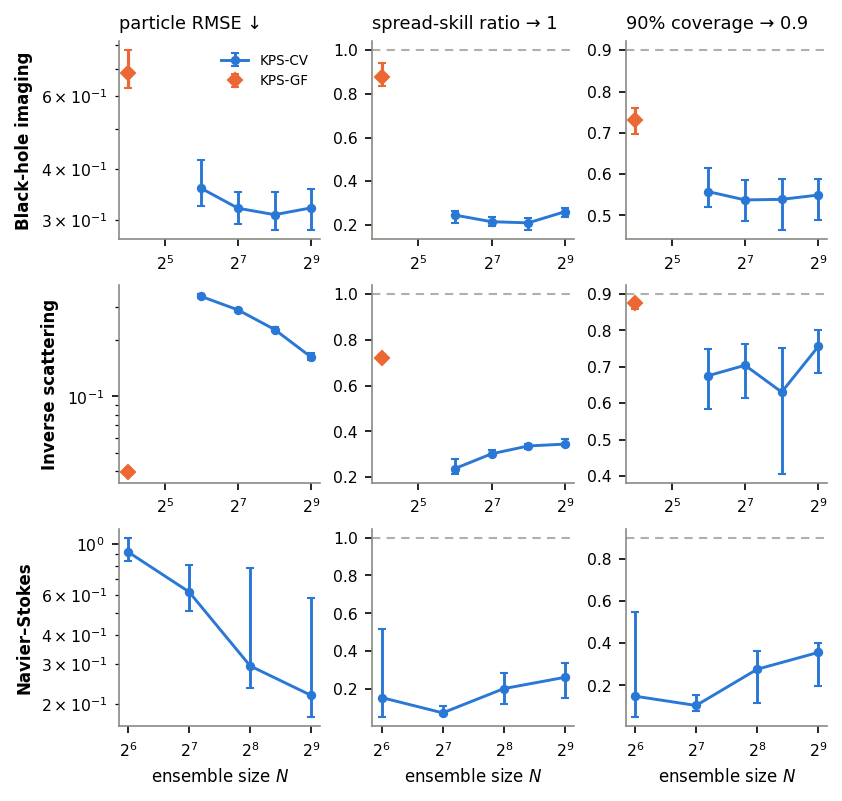

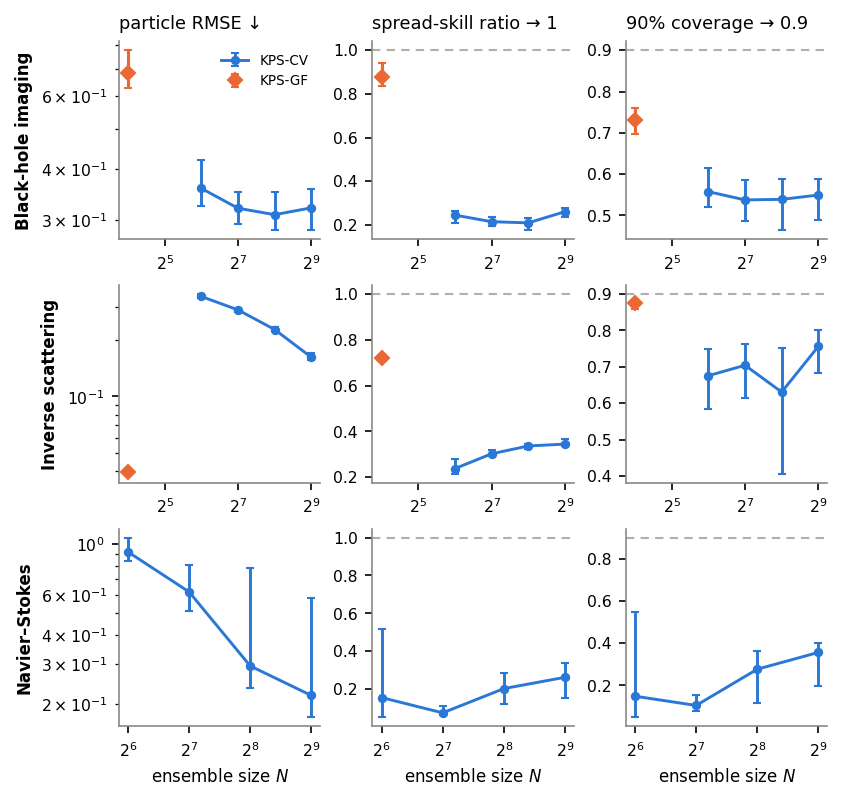

In [6]:
fig = pa.fig_particles(df, OUT / 'fig_particles.pdf')
pa.fig_particles(df, OUT / 'fig_particles.png')
plt.show()

## 6. Galleries

Uncertainty panels share **one** colour scale across ensemble sizes, so growth is visible.

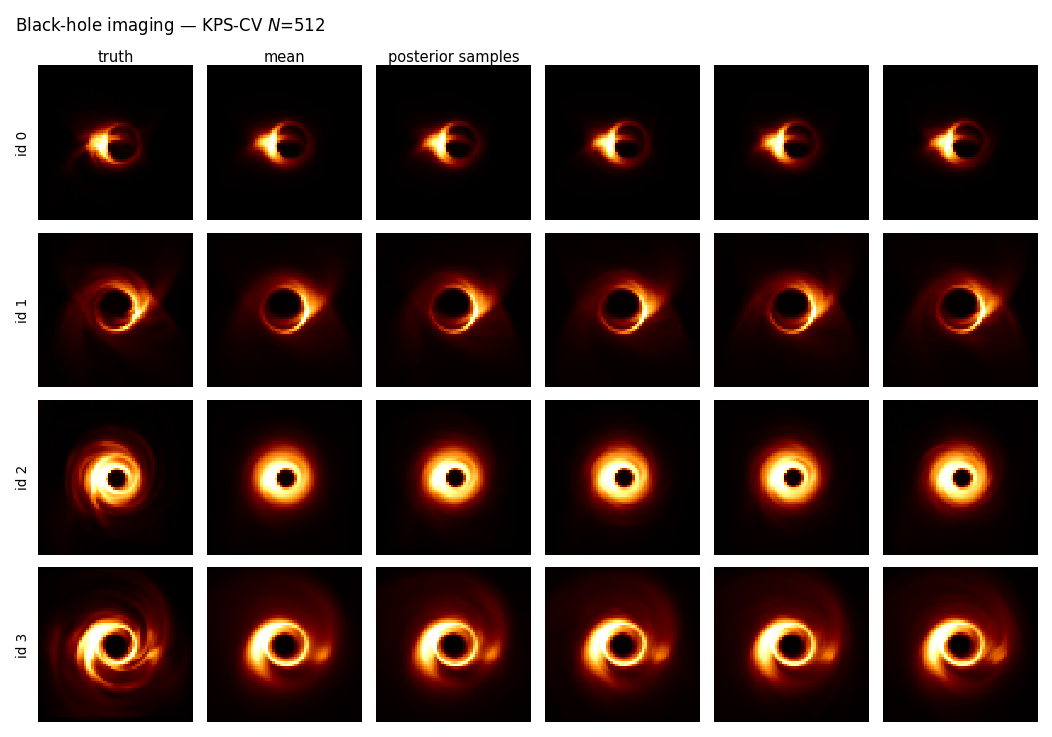

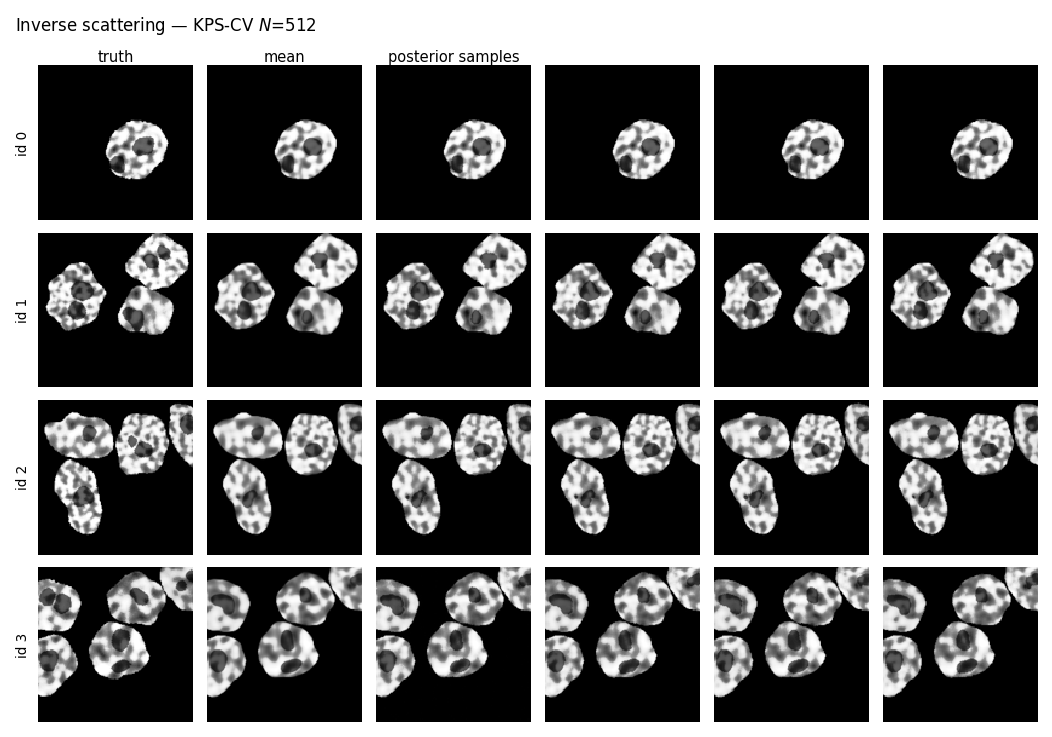

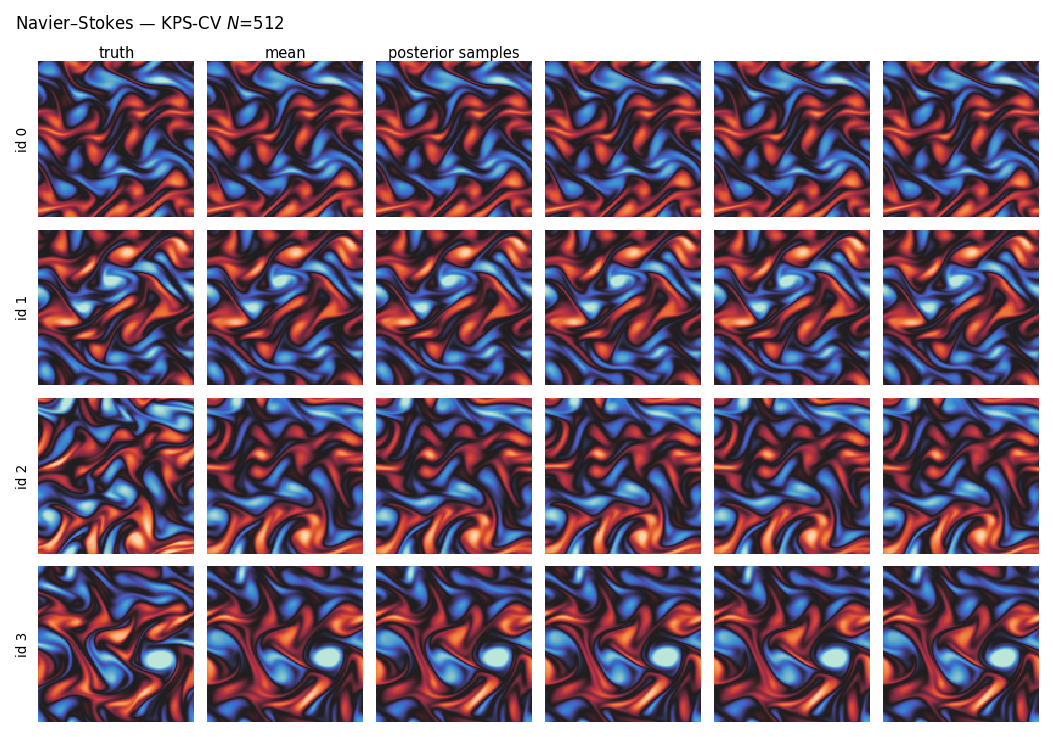

In [7]:
for prob, algo, run in [('blackhole', 'KPSCV', 'gen_cv_N512'),
                        ('inv-scatter', 'KPSCV', 'gen_cv_N512'),
                        ('navier-stokes', 'KPSCV', 'gen_cv_N512')]:
    pa.fig_gallery_instances(prob, algo, run, ids=(0, 1, 2, 3),
                             out=OUT / f'fig_gallery_{prob}.pdf')
    plt.show()

## 7. TARP

Recomputed from arrays here rather than taken from `KPS/kps/metrics.py`, which needs a callable
sampler. `tarp_selftest` runs first: its first version reported a calibrated case as badly
over-dispersed, and the fault was the **test**, not the statistic.

In [8]:
res = pa.tarp_selftest()
print(f"{'case':<22}{'max above':>12}{'max below':>12}{'rms dev':>10}")
for k, (a, c, hi, lo) in res.items():
    print(f'{k:<22}{hi:>+12.3f}{lo:>+12.3f}{np.sqrt(((c - a) ** 2).mean()):>10.3f}')
print('\nexpected: calibrated ~0 on both; x2 strongly +; x0.5 strongly -')

case                     max above   max below   rms dev
calibrated                  +0.026      -0.002     0.016
over-dispersed x2           +0.947      +0.000     0.570
over-confident x0.5         +0.001      -0.734     0.474

expected: calibrated ~0 on both; x2 strongly +; x0.5 strongly -


In [9]:
# THE PARTICLE LADDER, not one N per arm: KPS-CV is stored at N=64..512 on all three problems,
# and the TARP curve moving with N is the point -- a single curve cannot show it. ~30s each.
TARP_JOBS = [(p, 'KPSCV', f'gen_cv_N{n}', n)
             for p in ('blackhole', 'inv-scatter', 'navier-stokes')
             for n in (64, 128, 256, 512)]
TARP_JOBS += [(p, 'KPSGF', 'gen_gf', 16) for p in ('blackhole', 'inv-scatter')]

cache = OUT / 'tarp_ladder.pkl'
if cache.exists():
    curves = pickle.load(open(cache, 'rb'))
else:
    curves = []
    for prob, algo, run, N in TARP_JOBS:
        ids = range(10) if prob == 'navier-stokes' else range(100)
        curves.append((prob, f'{pa.LBL[algo]} N={N}', pa.tarp(prob, algo, run, ids)))
    pickle.dump(curves, open(cache, 'wb'))

print(f"{'problem':<15}{'method':<16}{'rms dev':>9}{'mean f':>9}")
for prob, lab, (a, c, fs) in curves:
    print(f'{prob:<15}{lab:<16}{np.sqrt(((c - a) ** 2).mean()):>9.3f}{fs.mean():>9.3f}')

plt.show()

problem        method            rms dev   mean f
blackhole      KPS-CV N=64         0.273    0.709
blackhole      KPS-CV N=128        0.269    0.675
blackhole      KPS-CV N=256        0.270    0.682
blackhole      KPS-CV N=512        0.264    0.721
inv-scatter    KPS-CV N=64         0.454    0.880
inv-scatter    KPS-CV N=128        0.535    0.976
inv-scatter    KPS-CV N=256        0.557    0.997
inv-scatter    KPS-CV N=512        0.559    0.999
navier-stokes  KPS-CV N=64         0.489    0.900
navier-stokes  KPS-CV N=128        0.545    1.000
navier-stokes  KPS-CV N=256        0.507    0.992
navier-stokes  KPS-CV N=512        0.439    0.965
blackhole      KPS-GF N=16         0.128    0.621
inv-scatter    KPS-GF N=16         0.321    0.789


## 8. Rank histogram and MIRA

`x_rank` in the cache is **not** a rank histogram — it averages over the whole field and is
dome-shaped for any dispersion. `pa.rank_hist` computes the classical statistic (rank the truth
among the members **per pixel**, pooled). MIRA's calibrated value is 2/3, derived rather than
assumed; `mira_selftest` runs first for the same reason as the TARP one.

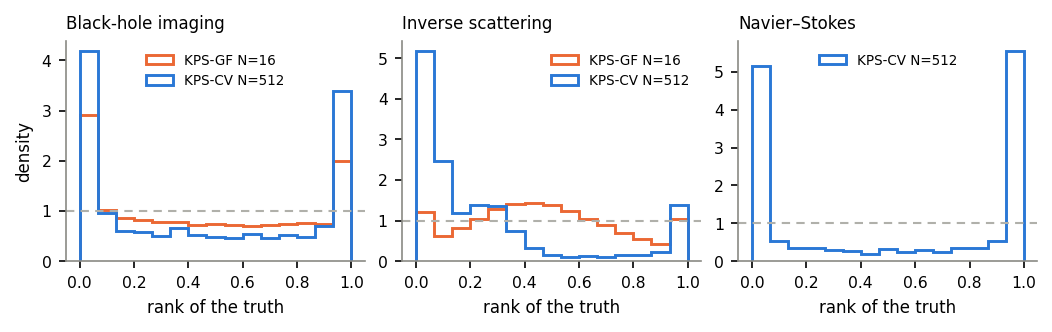

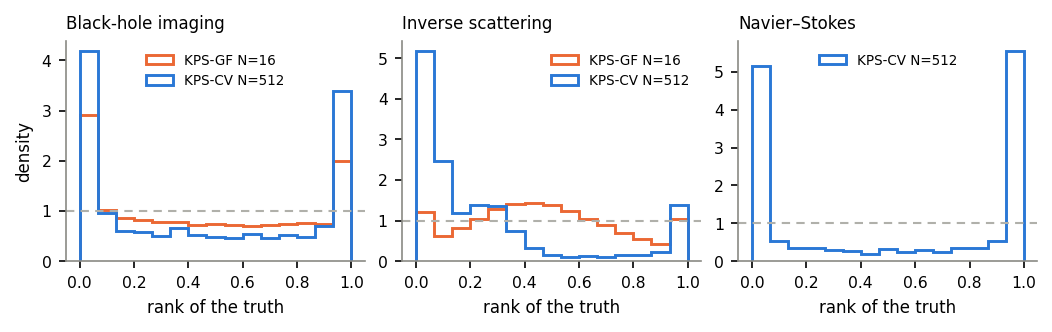

problem        method           frac at edges   (0.10 = flat = calibrated)


blackhole      KPS-GF N=16              0.189


blackhole      KPS-CV N=512             0.471


inv-scatter    KPS-GF N=16              0.086


inv-scatter    KPS-CV N=512             0.365


navier-stokes  KPS-CV N=512             0.688


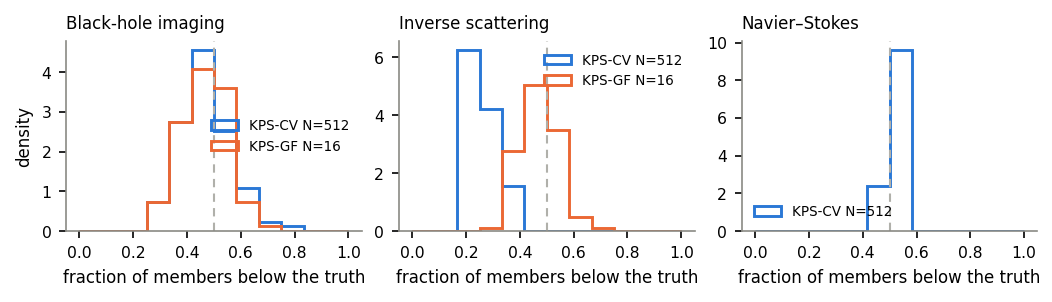


above: MEAN BIAS, not dispersion - 0.5 is unbiased, away from 0.5 is a shifted mean

case                         MIRA     std   expected
calibrated (->0.667)       0.6604  0.0200   0.667
over-confident x0.3        0.5679  0.0238   < 0.667
over-dispersed x3          0.6064  0.0224   < 0.667
unpaired (->0.5)           0.5516  0.0245   0.500



problem        method               MIRA     std  inst   (0.667 calibrated, 0.5 uncalibrated)
blackhole      KPS-GF N=16        0.6661  0.0282    60
blackhole      KPS-CV N=512       0.5714  0.0422    60
inv-scatter    KPS-GF N=16        0.6484  0.0279    60
inv-scatter    KPS-CV N=512       0.5161  0.0302    60
navier-stokes  KPS-CV N=512       0.5382  0.0996    10
--- tab_mira.tex --------------------------------------------------
\begin{tabular}{llcc}
\toprule
Problem & Method & MIRA $\to 2/3$ & instances \\
\midrule
Black-hole imaging & KPS-GF N=16 & $0.6661 \pm 0.0282$ & 60 \\
Black-hole imaging & KPS-CV N=512 & $0.5714 \pm 0.0422$ & 60 \\
Inverse scattering & KPS-GF N=16 & $0.6484 \pm 0.0279$ & 60 \\
Inverse scattering & KPS-CV N=512 & $0.5161 \pm 0.0302$ & 60 \\
Navier--Stokes & KPS-CV N=512 & $0.5382 \pm 0.0996$ & 10 \\
\bottomrule
\end{tabular}


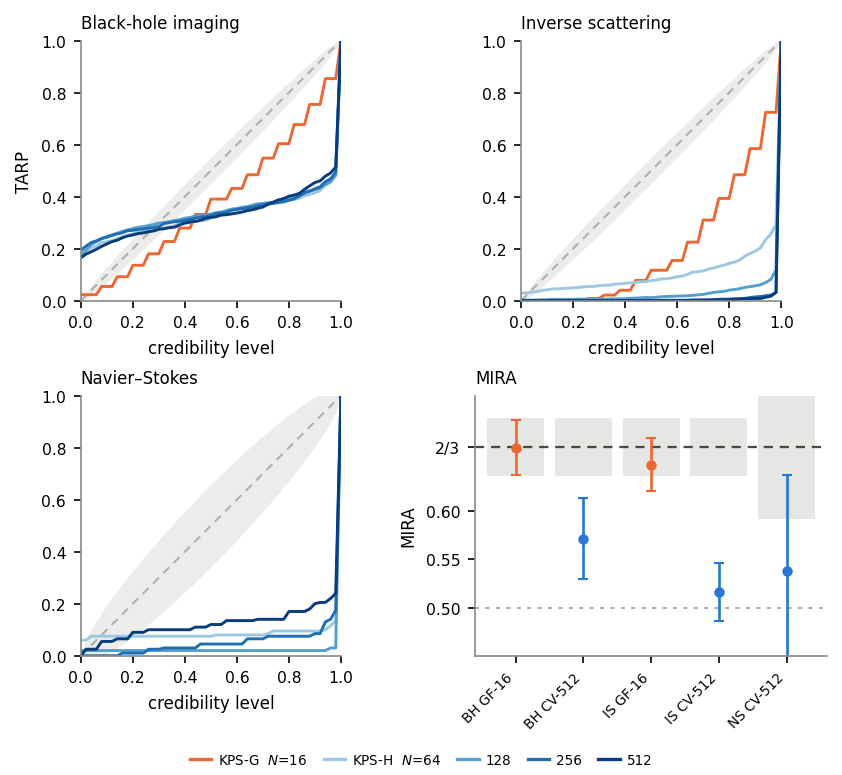

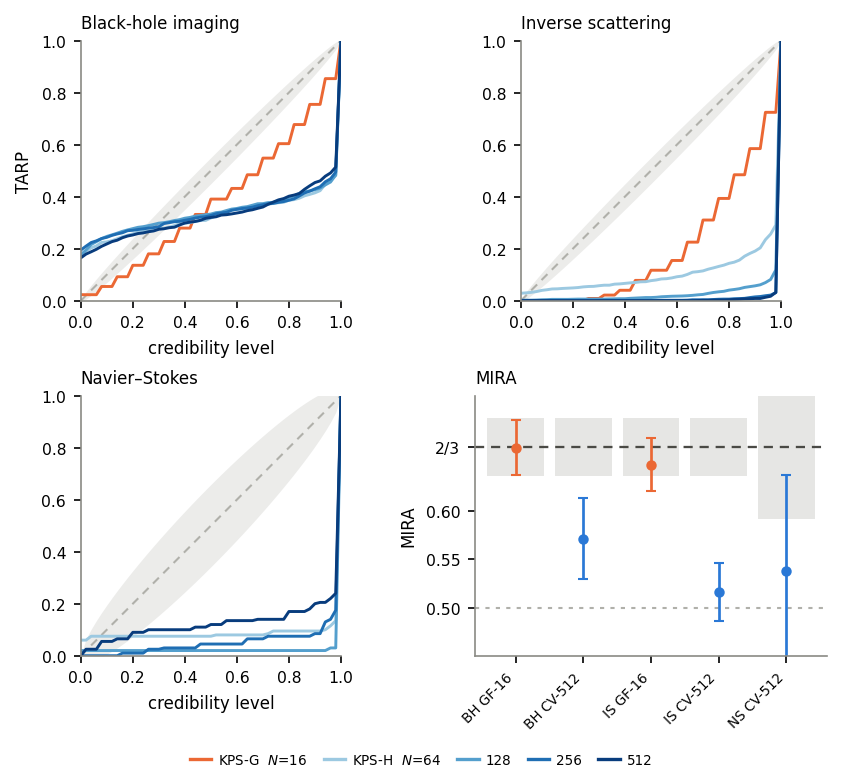

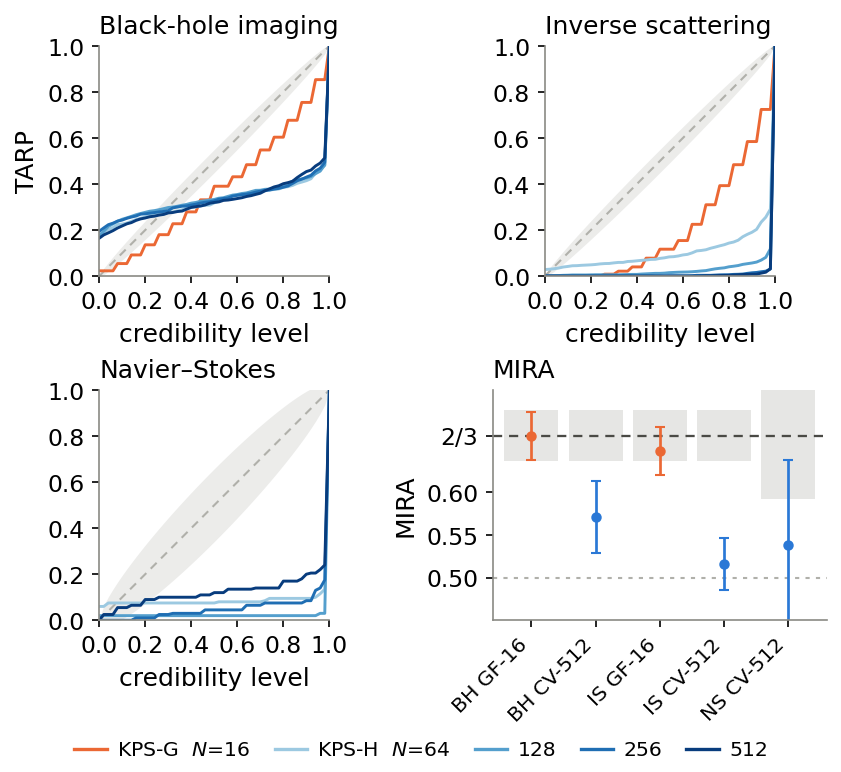

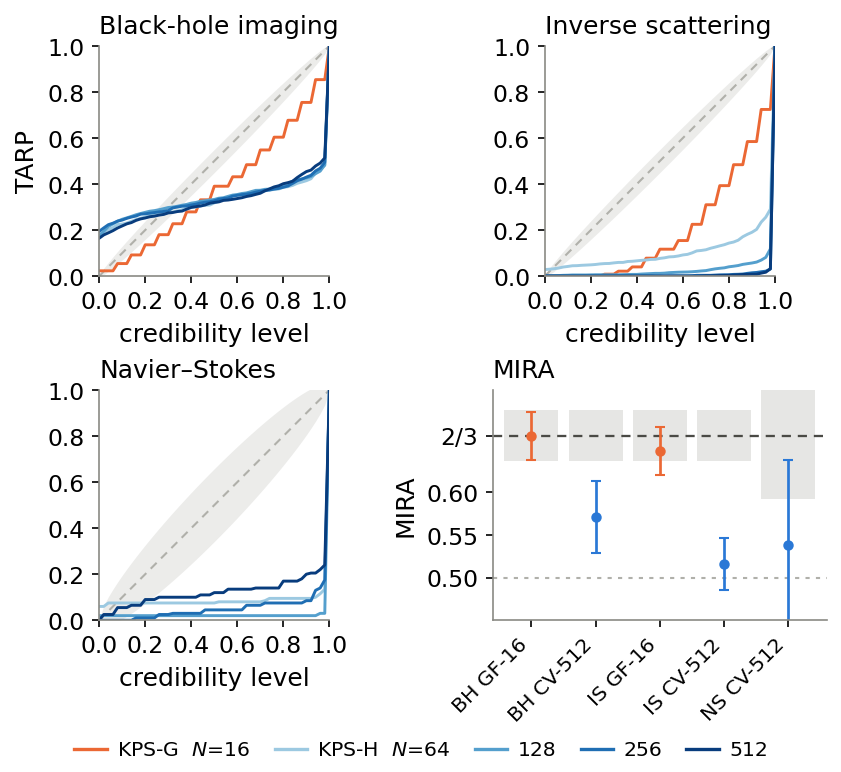

problem        method         |score-2/3|    band   verdict
blackhole      KPS-GF N=16         0.0006  0.0304   indistinguishable from calibrated
blackhole      KPS-CV N=512        0.0952  0.0304   miscalibrated
inv-scatter    KPS-GF N=16         0.0182  0.0304   indistinguishable from calibrated
inv-scatter    KPS-CV N=512        0.1506  0.0304   miscalibrated
navier-stokes  KPS-CV N=512        0.1285  0.0745   miscalibrated


In [10]:
JOBS = [('blackhole', 'KPSGF', 'gen_gf', range(60)),
        ('blackhole', 'KPSCV', 'gen_cv_N512', range(60)),
        ('inv-scatter', 'KPSGF', 'gen_gf', range(60)),
        ('inv-scatter', 'KPSCV', 'gen_cv_N512', range(60)),
        ('navier-stokes', 'KPSCV', 'gen_cv_N512', range(10))]

pa.fig_rank(JOBS, out=OUT / 'fig_rankhist.pdf')
pa.fig_rank(JOBS, out=OUT / 'fig_rankhist.png')
plt.show()

print(f"{'problem':<15}{'method':<16}{'frac at edges':>14}   (0.10 = flat = calibrated)")
for prob, algo, run, ids in JOBS:
    r = pa.rank_hist(prob, algo, run, ids)
    N = run.split('_N')[-1] if '_N' in run else '16'
    print(f'{prob:<15}{pa.LBL[algo] + " N=" + N:<16}'
          f'{float(((r < 0.05) | (r > 0.95)).mean()):>14.3f}')

# the cached x_rank, shown for what it actually is
fig, ax = plt.subplots(1, 3, figsize=(6.9, 1.9), squeeze=False)
for a, prob in zip(ax[0], ('blackhole', 'inv-scatter', 'navier-stokes')):
    d = df[(df.problem == prob) & (df.x_mean_l2 <= pa.DIVERGED)]
    for algo, ga in d.groupby('algo'):
        big = ga[ga.n == ga.n.max()]
        a.hist(big.x_rank, bins=12, range=(0, 1), histtype='step', density=True,
               color=pa.C[algo], lw=1.4, label=f'{pa.LBL[algo]} N={int(big.n.iloc[0])}')
    a.axvline(0.5, color='#b0b0aa', ls=(0, (4, 3)), lw=1)
    a.set_title(pa.PLAIN[prob], loc='left', fontsize=8)
    a.set_xlabel('fraction of members below the truth')
    a.legend(fontsize=6.5)
ax[0][0].set_ylabel('density')
plt.savefig(OUT / 'fig_bias.pdf', bbox_inches='tight')
plt.savefig(OUT / 'fig_bias.png', bbox_inches='tight')
plt.show()
print('\nabove: MEAN BIAS, not dispersion - 0.5 is unbiased, away from 0.5 is a shifted mean')

# ---- MIRA -----------------------------------------------------------------
print()
print(f"{'case':<24}{'MIRA':>9}{'std':>8}   expected")
_exp = {'calibrated (->0.667)': '0.667', 'over-confident x0.3': '< 0.667',
        'over-dispersed x3': '< 0.667', 'unpaired (->0.5)': '0.500'}
for _k, (_sc, _sd) in pa.mira_selftest().items():
    print(f'{_k:<24}{_sc:>9.4f}{_sd:>8.4f}   {_exp.get(_k, "")}')

mira_cache = OUT / 'mira.pkl'
if mira_cache.exists():
    mres = pickle.load(open(mira_cache, 'rb'))
else:
    mres = pa.mira_campaign(JOBS, num_runs=30, max_members=64)
    pickle.dump(mres, open(mira_cache, 'wb'))

print()
print(f"{'problem':<15}{'method':<16}{'MIRA':>9}{'std':>8}{'inst':>6}"
      "   (0.667 calibrated, 0.5 uncalibrated)")
for prob, lab, sc, sd, n in mres:
    print(f'{prob:<15}{lab:<16}{sc:>9.4f}{sd:>8.4f}{n:>6}')

_rows = [r'\begin{tabular}{llcc}', r'\toprule',
         r'Problem & Method & MIRA $\to 2/3$ & instances \\', r'\midrule']
for prob, lab, sc, sd, n in mres:
    _rows.append(f'{pa.NICE[prob]} & {lab} & ${sc:.4f} \\pm {sd:.4f}$ & {n} \\\\')
_rows += [r'\bottomrule', r'\end{tabular}']
emit('tab_mira.tex', '\n'.join(_rows))

# TARP and MIRA on one row. The MIRA band is sqrt(1/(18L)), the spread expected from a FINITE
# number of ground truths: a point inside it is not distinguishable from perfectly calibrated
# at that L. NS has L=10, so its band is wide and "inside" means UNDERPOWERED.
pa.fig_calibration(curves, mres, out=OUT / 'fig_calibration.pdf')
pa.fig_calibration(curves, mres, out=OUT / 'fig_calibration.png')
pa.fig_calibration(curves, mres, out=OUT / 'fig_calibration_halfcol.pdf', scale=1.5)
pa.fig_calibration(curves, mres, out=OUT / 'fig_calibration_halfcol.png', scale=1.5)
plt.show()

print(f"{'problem':<15}{'method':<14}{'|score-2/3|':>12}{'band':>8}   verdict")
for prob, lab, sc, sd, n in mres:
    band = (1 / (18 * n)) ** 0.5
    print(f'{prob:<15}{lab:<14}{abs(sc - 2/3):>12.4f}{band:>8.4f}   '
          f'{"indistinguishable from calibrated" if abs(sc - 2/3) < band else "miscalibrated"}')

## 9. Posterior predictive check (observation space)

The diagnostic that separates two failure modes: a method can be calibrated in observation
space and collapsed in state space, which says the difficulty is the null space rather than the
fit.

--- tab_ppc.tex ---------------------------------------------------
\small
\begin{tabular}{llcccc}
\toprule
Method & $N$ & \shortstack{particle\\RMSE $\downarrow$} & \shortstack{CRPS\\$\downarrow$} & \shortstack{spread-skill\\ratio $\to 1$} & \shortstack{90\% coverage\\$\to 0.9$} \\
\midrule
\multicolumn{6}{l}{\itshape Black-hole imaging} \\
KPS-H & 64 & $0.0712 \pm 0.0308$ & $0.0173 \pm 0.0075$ & $0.852 \pm 0.155$ & $0.847 \pm 0.037$ \\
KPS-H & 128 & $0.0636 \pm 0.0284$ & $0.0148 \pm 0.0065$ & $0.955 \pm 0.389$ & $0.875 \pm 0.032$ \\
KPS-H & 256 & $0.0587 \pm 0.0273$ & $0.0130 \pm 0.0057$ & $0.967 \pm 0.134$ & $0.894 \pm 0.024$ \\
KPS-H & 512 & $0.0549 \pm 0.0252$ & $0.0120 \pm 0.0056$ & $1.047 \pm 0.209$ & $0.909 \pm 0.019$ \\
KPS-H & 16 & $0.0726 \pm 0.0345$ & $0.0156 \pm 0.0073$ & $1.048 \pm 0.230$ & $0.850 \pm 0.059$ \\
\midrule
\multicolumn{6}{l}{\itshape Inverse scattering} \\
KPS-H & 64 & $0.0834 \pm 0.0090$ & $0.0436 \pm 0.0056$ & $0.305 \pm 0.131$ & $0.454 \pm 0.110$ \\
KPS-H

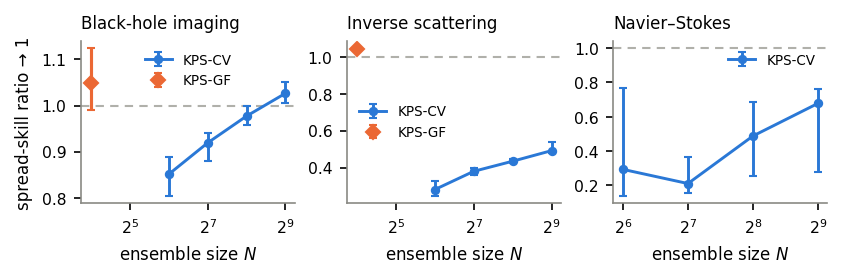

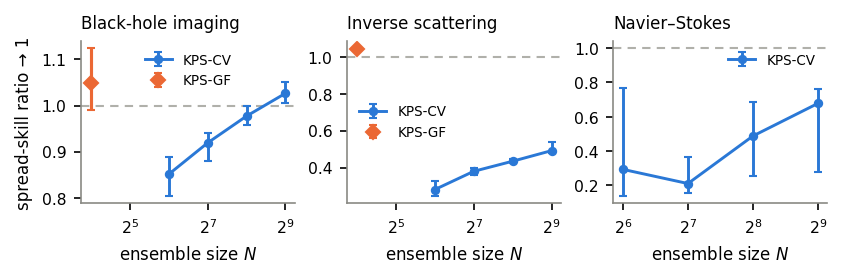

solid = observation space, dashed = state space; the gap is the part of the
posterior the data does not constrain.


In [11]:
emit('tab_ppc.tex', pa.ppc_table(df))
emit('tab_ppc_median.tex', pa.ppc_table_median(df))

pa.fig_ppc(df, out=OUT / 'fig_ppc.pdf')
pa.fig_ppc(df, out=OUT / 'fig_ppc.png')
plt.show()
print('solid = observation space, dashed = state space; the gap is the part of the')
print('posterior the data does not constrain.')

## What this notebook deliberately does not do

* **It does not touch `notebooks/paper/`.** Those are the ladder's assets and are what the
  current paper draft uses.
* **It does not re-run a sampler.** Everything reads `scripts/metrics_cv.csv` and the stored
  result files.
* **It does not restate the baselines.** They are the same published numbers as the ladder
  notebook, with the same unverified-transcription caveat.

Open, and worth settling before any of this is quoted: the ladder campaign's GPU-hours are
measured, the ridge-SLR campaign's are **estimated** for inverse scattering and Navier–Stokes
(`gen_samples_cv.py --assume`). `--probe` replaces them with measurements without touching the
samples.